# Stress Suite For All Methods

This notebook stress-tests all implemented methods across several situations:

- ACI with IPCW
- ACI without IPCW
- AdaFTRL
- AdaFTRL-V2 / `adaftrl_v2`
- `XuLPB`, a pure model-based online Cox LPB baseline

The suite includes ordinary stochastic censoring regimes, stronger censoring regimes, stronger model bias, and a long censor-only tail where from a switch round onward only censored observations are presented. `XuLPB` keeps `tau = alpha` fixed and uses only its online Cox survival curve, without ACI, AdaFTRL, IPCW calibration, or adaptive tau updates.

In [4]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from online_survival.experiments import (
    SimulationConfig,
    behavior_svg,
    format_markdown_table,
    run_censor_only_stress_experiment,
    run_one_experiment,
    run_repeated_censor_only_stress_experiments,
    run_repeated_experiments,
    summarize_one_run,
    summarize_repeats,
)


def show_markdown(markdown):
    try:
        from IPython.display import Markdown, display
        display(Markdown(markdown))
    except Exception:
        print(markdown)


def show_svg(svg):
    try:
        from IPython.display import SVG, display
        display(SVG(svg))
    except Exception:
        print(svg[:1000])


SUMMARY_COLUMNS = [
    "situation",
    "algorithm",
    "realized_coverage_mean",
    "coverage_shortfall_mean",
    "coverage_abs_error_mean",
    "average_conditional_coverage_mean",
    "average_surrogate_error_mean",
    "average_lower_bound_mean",
    "ambiguous_below_bound_fraction_mean",
    "final_tau_mean",
    "censoring_fraction_mean",
]

ONE_RUN_COLUMNS = [
    "algorithm",
    "realized_coverage",
    "target_coverage",
    "coverage_shortfall",
    "coverage_abs_error",
    "average_conditional_coverage",
    "average_surrogate_error",
    "average_lower_bound",
    "ambiguous_below_bound_fraction",
    "final_tau",
    "censoring_fraction",
]


def add_situation(rows, situation):
    return [{"situation": situation, **row} for row in rows]


def repeated_summary_for_scenario(scenario):
    if scenario["kind"] == "regular":
        repeated = run_repeated_experiments(
            scenario["config"],
            n_repeats=scenario["n_repeats"],
            seed=scenario["seed"],
            include_adaftrl_v2=True,
            include_xu_lpb=True,
        )
    else:
        repeated = run_repeated_censor_only_stress_experiments(
            scenario["config"],
            n_repeats=scenario["n_repeats"],
            seed=scenario["seed"],
            censor_only_start=scenario["censor_only_start"],
            forced_censor_fraction=scenario["forced_censor_fraction"],
            include_adaftrl_v2=True,
            include_xu_lpb=True,
        )
    return add_situation(summarize_repeats(repeated), scenario["name"])


def one_run_for_scenario(scenario):
    if scenario["kind"] == "regular":
        return run_one_experiment(
            scenario["config"],
            seed=scenario["one_run_seed"],
            include_adaftrl_v2=True,
            include_xu_lpb=True,
        )
    return run_censor_only_stress_experiment(
        scenario["config"],
        seed=scenario["one_run_seed"],
        censor_only_start=scenario["censor_only_start"],
        forced_censor_fraction=scenario["forced_censor_fraction"],
        include_adaftrl_v2=True,
        include_xu_lpb=True,
    )

## Scenarios

All scenarios use target lower coverage `1 - alpha = 0.90`. The repeated-run table below reports means across seeds. Smaller `coverage_shortfall_mean` and `coverage_abs_error_mean` are better. `average_lower_bound_mean` is the average LPB value returned by each method.

In [5]:
scenarios = [
    {
        "name": "moderate censoring",
        "kind": "regular",
        "config": SimulationConfig(n_rounds=1000, censoring_rate=0.18, eta=0.010),
        "n_repeats": 40,
        "seed": 1100,
        "one_run_seed": 11,
    },
    {
        "name": "heavy censoring",
        "kind": "regular",
        "config": SimulationConfig(n_rounds=1000, censoring_rate=0.60, eta=0.008),
        "n_repeats": 40,
        "seed": 2100,
        "one_run_seed": 17,
    },
    {
        "name": "extreme censoring",
        "kind": "regular",
        "config": SimulationConfig(n_rounds=1000, censoring_rate=0.90, eta=0.008),
        "n_repeats": 40,
        "seed": 3100,
        "one_run_seed": 23,
    },
    {
        "name": "strong upward model bias",
        "kind": "regular",
        "config": SimulationConfig(
            n_rounds=1000,
            censoring_rate=0.45,
            eta=0.008,
            model_log_shift=0.55,
        ),
        "n_repeats": 40,
        "seed": 4100,
        "one_run_seed": 29,
    },
    {
        "name": "long censor-only tail",
        "kind": "censor_only",
        "config": SimulationConfig(n_rounds=5000, censoring_rate=0.18, eta=0.010),
        "censor_only_start": 300,
        "forced_censor_fraction": 0.20,
        "n_repeats": 20,
        "seed": 5100,
        "one_run_seed": 5,
    },
]

all_summary = []
for scenario in scenarios:
    all_summary.extend(repeated_summary_for_scenario(scenario))

show_markdown(format_markdown_table(all_summary, SUMMARY_COLUMNS, digits=4))

Repeated experiments:   0%|          | 0/40 [00:00<?, ?it/s]

Repeated experiments:   0%|          | 0/40 [00:00<?, ?it/s]

Repeated experiments:   0%|          | 0/40 [00:00<?, ?it/s]

Repeated experiments:   0%|          | 0/40 [00:00<?, ?it/s]

Censor-only stress experiments:   0%|          | 0/20 [00:00<?, ?it/s]

| situation | algorithm | realized_coverage_mean | coverage_shortfall_mean | coverage_abs_error_mean | average_conditional_coverage_mean | average_surrogate_error_mean | average_lower_bound_mean | ambiguous_below_bound_fraction_mean | final_tau_mean | censoring_fraction_mean |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| moderate censoring | ACI with IPCW | 0.8931 | 0.0071 | 0.0072 | 0.8946 | 0.1068 | 1.3767 | 0.2130 | 0.0335 | 0.4081 |
| moderate censoring | ACI without IPCW | 0.9742 | 0.0000 | 0.0742 | 0.9745 | 0.1620 | 0.8558 | 0.1403 | 0.0058 | 0.4081 |
| moderate censoring | AdaFTRL | 0.8873 | 0.0127 | 0.0127 | 0.8892 | 0.1122 | 1.4095 | 0.2177 | 0.0351 | 0.4081 |
| moderate censoring | AdaFTRL-V2 | 0.9065 | 0.0002 | 0.0069 | 0.9085 | 0.0928 | 1.3268 | 0.2082 | 0.0273 | 0.4081 |
| moderate censoring | XuLPB | 0.9838 | 0.0000 | 0.0838 | 0.9840 | 0.1406 | 0.7616 | 0.1267 | 0.1000 | 0.4081 |
| heavy censoring | ACI with IPCW | 0.8924 | 0.0082 | 0.0089 | 0.8920 | 0.1088 | 1.3853 | 0.5450 | 0.0352 | 0.7765 |
| heavy censoring | ACI without IPCW | 0.9903 | 0.0000 | 0.0903 | 0.9903 | 0.3087 | 0.6292 | 0.3025 | 0.0011 | 0.7765 |
| heavy censoring | AdaFTRL | 0.8734 | 0.0266 | 0.0266 | 0.8720 | 0.1274 | 1.4803 | 0.5694 | 0.0381 | 0.7765 |
| heavy censoring | AdaFTRL-V2 | 0.9091 | 0.0004 | 0.0099 | 0.9093 | 0.0918 | 1.3177 | 0.5289 | 0.0184 | 0.7765 |
| heavy censoring | XuLPB | 0.9812 | 0.0000 | 0.0812 | 0.9815 | 0.3525 | 0.7349 | 0.3404 | 0.1000 | 0.7765 |
| extreme censoring | ACI with IPCW | 0.8900 | 0.0131 | 0.0162 | 0.8902 | 0.1110 | 1.3848 | 0.6850 | 0.0345 | 0.8726 |
| extreme censoring | ACI without IPCW | 0.9925 | 0.0000 | 0.0925 | 0.9927 | 0.3842 | 0.5741 | 0.3802 | 0.0011 | 0.8726 |
| extreme censoring | AdaFTRL | 0.8288 | 0.0712 | 0.0712 | 0.8262 | 0.1721 | 1.6568 | 0.7466 | 0.0526 | 0.8726 |
| extreme censoring | AdaFTRL-V2 | 0.8545 | 0.0455 | 0.0455 | 0.8530 | 0.1458 | 1.5563 | 0.7287 | 0.0344 | 0.8726 |
| extreme censoring | XuLPB | 0.9798 | 0.0000 | 0.0798 | 0.9797 | 0.4842 | 0.7662 | 0.4743 | 0.1000 | 0.8726 |
| strong upward model bias | ACI with IPCW | 0.8825 | 0.0175 | 0.0175 | 0.8798 | 0.1199 | 1.4159 | 0.4473 | 0.0147 | 0.6909 |
| strong upward model bias | ACI without IPCW | 0.9743 | 0.0000 | 0.0743 | 0.9742 | 0.3068 | 0.8077 | 0.2898 | 0.0016 | 0.6909 |
| strong upward model bias | AdaFTRL | 0.8510 | 0.0490 | 0.0490 | 0.8486 | 0.1516 | 1.5643 | 0.4821 | 0.0138 | 0.6909 |
| strong upward model bias | AdaFTRL-V2 | 0.8830 | 0.0170 | 0.0170 | 0.8801 | 0.1192 | 1.4353 | 0.4560 | 0.0073 | 0.6909 |
| strong upward model bias | XuLPB | 0.9763 | 0.0000 | 0.0762 | 0.9766 | 0.3160 | 0.8156 | 0.2995 | 0.1000 | 0.6909 |
| long censor-only tail | ACI with IPCW | 0.3521 | 0.5478 | 0.5478 | 0.3518 | 0.0073 | 3.5088 | 0.9536 | 0.5000 | 0.9643 |
| long censor-only tail | ACI without IPCW | 0.9952 | 0.0000 | 0.0952 | 0.9953 | 0.5051 | 0.4971 | 0.5034 | 0.0002 | 0.9643 |
| long censor-only tail | AdaFTRL | 0.3417 | 0.5583 | 0.5583 | 0.3417 | 0.0074 | 3.5553 | 0.9538 | 0.5000 | 0.9643 |
| long censor-only tail | AdaFTRL-V2 | 0.9130 | 0.0023 | 0.0176 | 0.9128 | 0.0063 | 1.3119 | 0.9534 | 0.0282 | 0.9643 |
| long censor-only tail | XuLPB | 0.9764 | 0.0000 | 0.0764 | 0.9765 | 0.8952 | 0.8346 | 0.8939 | 0.1000 | 0.9643 |

## Representative One-Run Figures

Each figure has numeric ticks and explicit axes. For the long censor-only tail, the vertical dashed line marks the point where the stream switches to only censored observations.

### moderate censoring

| algorithm | realized_coverage | target_coverage | coverage_shortfall | coverage_abs_error | average_conditional_coverage | average_surrogate_error | average_lower_bound | ambiguous_below_bound_fraction | final_tau | censoring_fraction |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.8920 | 0.9000 | 0.0080 | 0.0080 | 0.8822 | 0.1055 | 1.4389 | 0.1940 | 0.0437 | 0.3930 |
| ACI without IPCW | 0.9740 | 0.9000 | 0.0000 | 0.0740 | 0.9690 | 0.1490 | 0.9242 | 0.1280 | 0.0050 | 0.3930 |
| AdaFTRL | 0.8890 | 0.9000 | 0.0110 | 0.0110 | 0.8720 | 0.1091 | 1.4867 | 0.2020 | 0.0446 | 0.3930 |
| AdaFTRL-V2 | 0.9070 | 0.9000 | 0.0000 | 0.0070 | 0.9010 | 0.0923 | 1.3691 | 0.1910 | 0.0333 | 0.3930 |
| XuLPB | 0.9850 | 0.9000 | 0.0000 | 0.0850 | 0.9870 | 0.1050 | 0.6375 | 0.0920 | 0.1000 | 0.3930 |

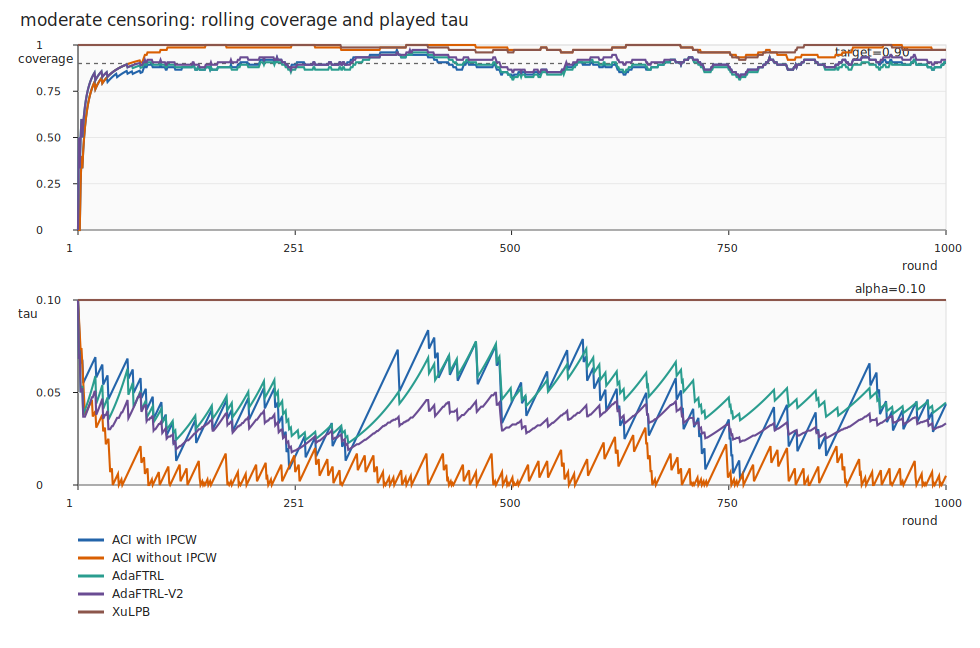

### heavy censoring

| algorithm | realized_coverage | target_coverage | coverage_shortfall | coverage_abs_error | average_conditional_coverage | average_surrogate_error | average_lower_bound | ambiguous_below_bound_fraction | final_tau | censoring_fraction |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.8850 | 0.9000 | 0.0150 | 0.0150 | 0.8789 | 0.1061 | 1.4460 | 0.5420 | 0.0504 | 0.7660 |
| ACI without IPCW | 0.9870 | 0.9000 | 0.0000 | 0.0870 | 0.9891 | 0.2960 | 0.6434 | 0.2870 | 0.0016 | 0.7660 |
| AdaFTRL | 0.8630 | 0.9000 | 0.0370 | 0.0370 | 0.8543 | 0.1182 | 1.5501 | 0.5690 | 0.0511 | 0.7660 |
| AdaFTRL-V2 | 0.9140 | 0.9000 | 0.0000 | 0.0140 | 0.9051 | 0.0871 | 1.3410 | 0.5230 | 0.0219 | 0.7660 |
| XuLPB | 0.9800 | 0.9000 | 0.0000 | 0.0800 | 0.9799 | 0.3740 | 0.7959 | 0.3640 | 0.1000 | 0.7660 |

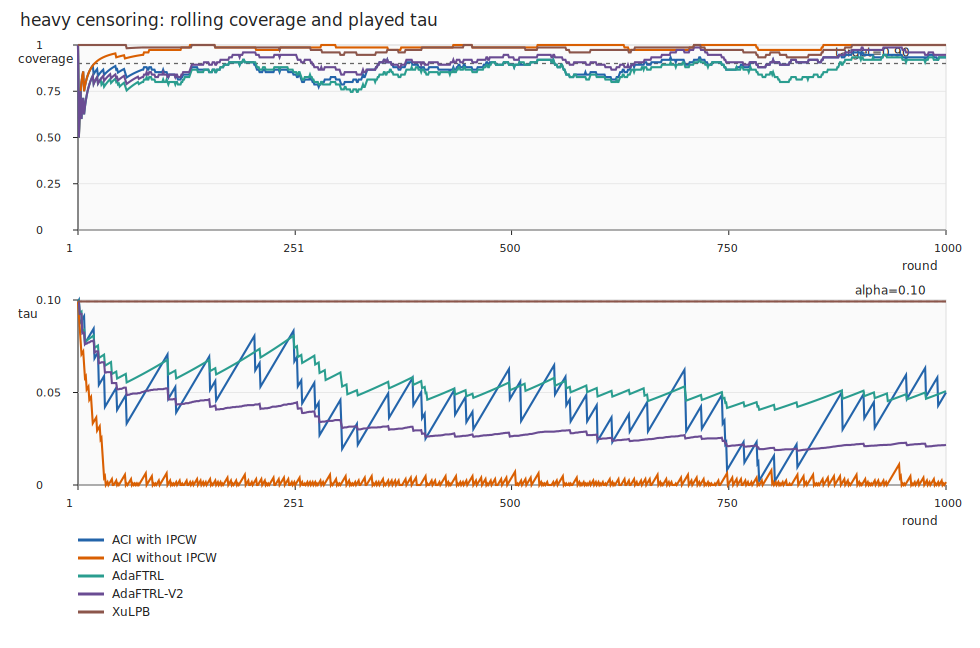

### extreme censoring

| algorithm | realized_coverage | target_coverage | coverage_shortfall | coverage_abs_error | average_conditional_coverage | average_surrogate_error | average_lower_bound | ambiguous_below_bound_fraction | final_tau | censoring_fraction |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.8970 | 0.9000 | 0.0030 | 0.0030 | 0.8925 | 0.1067 | 1.3733 | 0.7070 | 0.0459 | 0.8880 |
| ACI without IPCW | 0.9940 | 0.9000 | 0.0000 | 0.0940 | 0.9931 | 0.3810 | 0.5671 | 0.3780 | 0.0000 | 0.8880 |
| AdaFTRL | 0.8230 | 0.9000 | 0.0770 | 0.0770 | 0.8193 | 0.1556 | 1.6687 | 0.7630 | 0.0605 | 0.8880 |
| AdaFTRL-V2 | 0.8460 | 0.9000 | 0.0540 | 0.0540 | 0.8487 | 0.1303 | 1.5617 | 0.7430 | 0.0387 | 0.8880 |
| XuLPB | 0.9420 | 0.9000 | 0.0000 | 0.0420 | 0.9478 | 0.6080 | 1.0296 | 0.5890 | 0.1000 | 0.8880 |

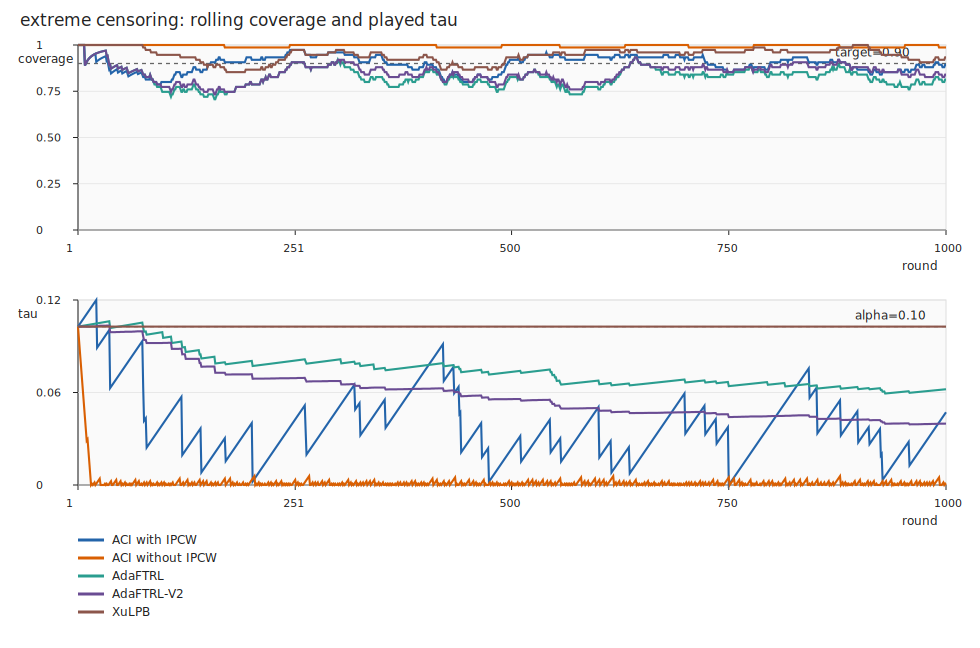

### strong upward model bias

| algorithm | realized_coverage | target_coverage | coverage_shortfall | coverage_abs_error | average_conditional_coverage | average_surrogate_error | average_lower_bound | ambiguous_below_bound_fraction | final_tau | censoring_fraction |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.8820 | 0.9000 | 0.0180 | 0.0180 | 0.8735 | 0.1144 | 1.4564 | 0.4610 | 0.0203 | 0.6840 |
| ACI without IPCW | 0.9720 | 0.9000 | 0.0000 | 0.0720 | 0.9763 | 0.3210 | 0.7927 | 0.3060 | 0.0032 | 0.6840 |
| AdaFTRL | 0.8450 | 0.9000 | 0.0550 | 0.0550 | 0.8408 | 0.1498 | 1.5954 | 0.4910 | 0.0144 | 0.6840 |
| AdaFTRL-V2 | 0.8780 | 0.9000 | 0.0220 | 0.0220 | 0.8792 | 0.1181 | 1.4410 | 0.4670 | 0.0072 | 0.6840 |
| XuLPB | 0.9870 | 0.9000 | 0.0000 | 0.0870 | 0.9908 | 0.2990 | 0.7353 | 0.2920 | 0.1000 | 0.6840 |

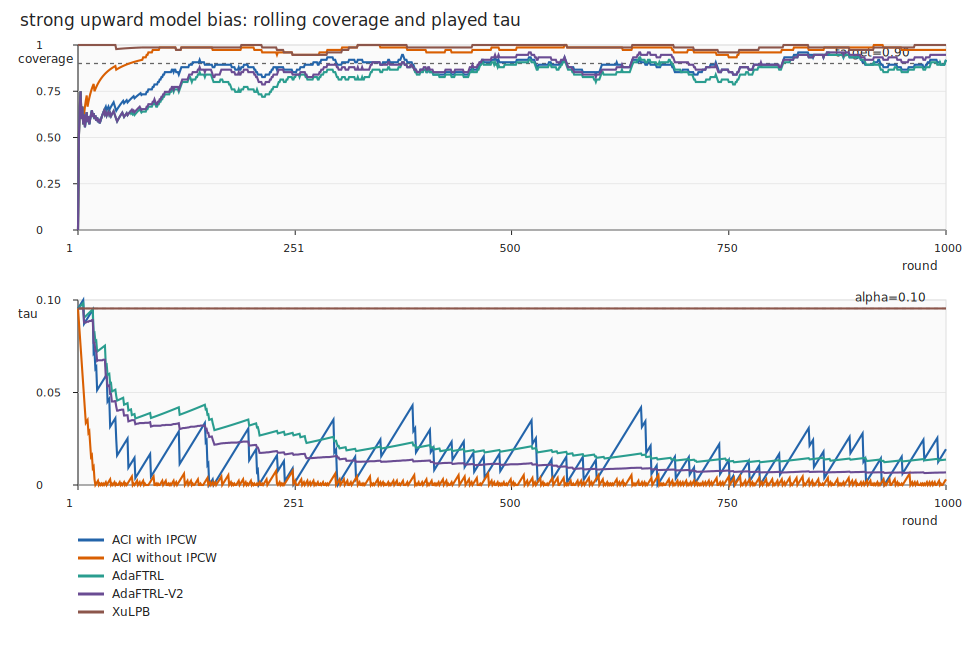

### long censor-only tail

| algorithm | realized_coverage | target_coverage | coverage_shortfall | coverage_abs_error | average_conditional_coverage | average_surrogate_error | average_lower_bound | ambiguous_below_bound_fraction | final_tau | censoring_fraction |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.3472 | 0.9000 | 0.5528 | 0.5528 | 0.3508 | 0.0072 | 3.5194 | 0.9548 | 0.5000 | 0.9660 |
| ACI without IPCW | 0.9964 | 0.9000 | 0.0000 | 0.0964 | 0.9954 | 0.5082 | 0.4963 | 0.5068 | 0.0010 | 0.9660 |
| AdaFTRL | 0.3388 | 0.9000 | 0.5612 | 0.5612 | 0.3419 | 0.0075 | 3.5602 | 0.9552 | 0.5000 | 0.9660 |
| AdaFTRL-V2 | 0.8956 | 0.9000 | 0.0044 | 0.0044 | 0.8962 | 0.0059 | 1.3904 | 0.9542 | 0.0351 | 0.9660 |
| XuLPB | 1.0000 | 0.9000 | 0.0000 | 0.1000 | 1.0000 | 0.0000 | 0.0000 | 0.0000 | 0.1000 | 0.9660 |

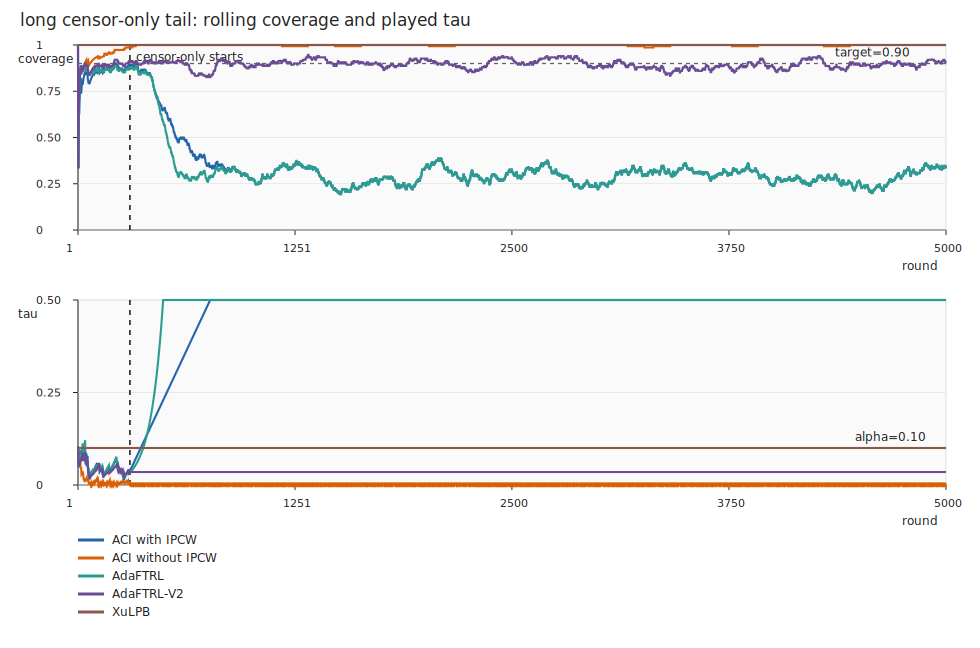

In [6]:
for scenario in scenarios:
    records = one_run_for_scenario(scenario)
    show_markdown(f"### {scenario['name']}")
    show_markdown(format_markdown_table(summarize_one_run(records), ONE_RUN_COLUMNS, digits=4))
    show_svg(
        behavior_svg(
            records,
            window=150 if scenario["kind"] == "censor_only" else 75,
            phase_change_round=scenario.get("censor_only_start"),
            title=f"{scenario['name']}: rolling coverage and played tau",
        )
    )